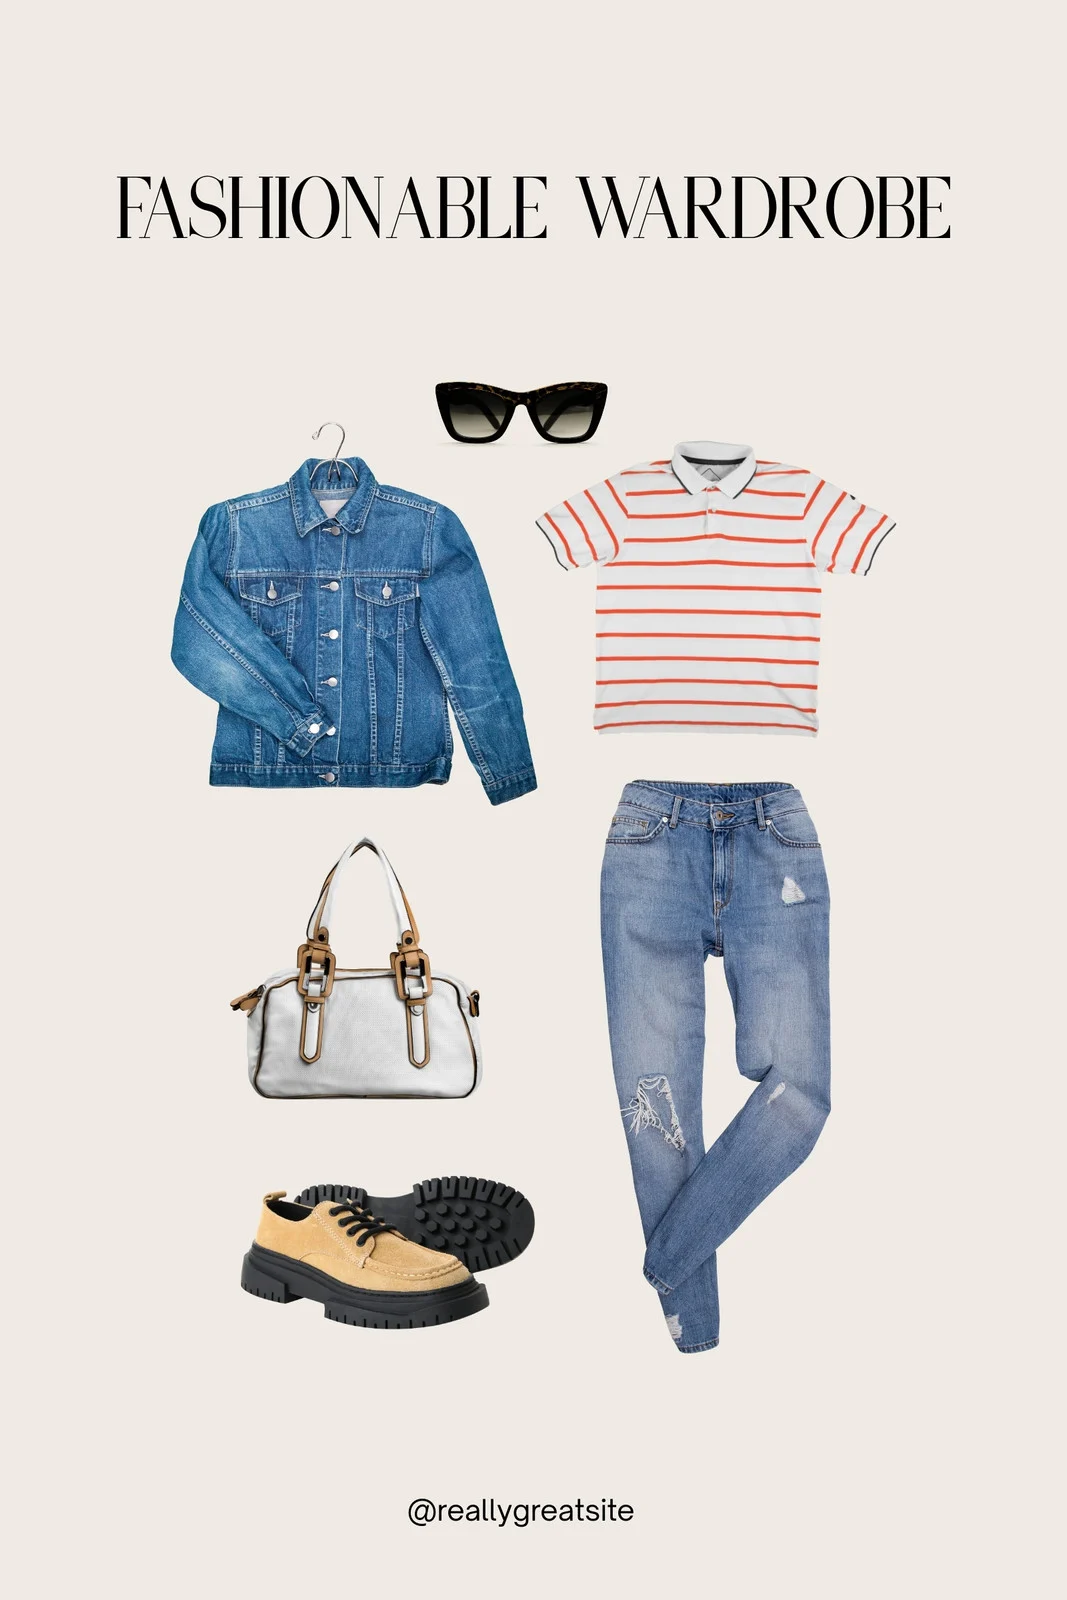

In [43]:
from pathlib import Path
from IPython.display import Image as DisplayImage, display
from PIL import Image as PILImage


canva_dir = Path('../datasets/original')
specs_dir = Path('../datasets/specs')
edits_dir = Path('../edits')

# Get all original Canva images (all formats)
canva_images = []
for ext in ['*.webp', '*.jpg', '*.jpeg', '*.png']:
    canva_images.extend(canva_dir.glob(ext))
canva_images = sorted(canva_images)

img_path = canva_images[0]
orig_w, orig_h = PILImage.open(img_path).size

# display at 1/4 the original width (keeps aspect ratio)
display(DisplayImage(filename=str(img_path), width=max(1, orig_w // 4)))

edit_images = []
for sub in edits_dir.iterdir():
    if sub.is_dir():
        edit_images.extend(sub.glob('render*.png'))
        edit_images.extend(sub.glob('render*.jpg'))
        edit_images.extend(sub.glob('render*.jpeg'))
        edit_images.extend(sub.glob('render*.webp'))
edit_images = sorted(edit_images)




In [6]:
from transformers import AutoProcessor, AutoModelForVision2Seq

model_name = "Qwen/Qwen3-VL-2B-Thinking"

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForVision2Seq.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

/Users/davidferris/Documents/envs/fonts-arm64/lib/python3.13/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


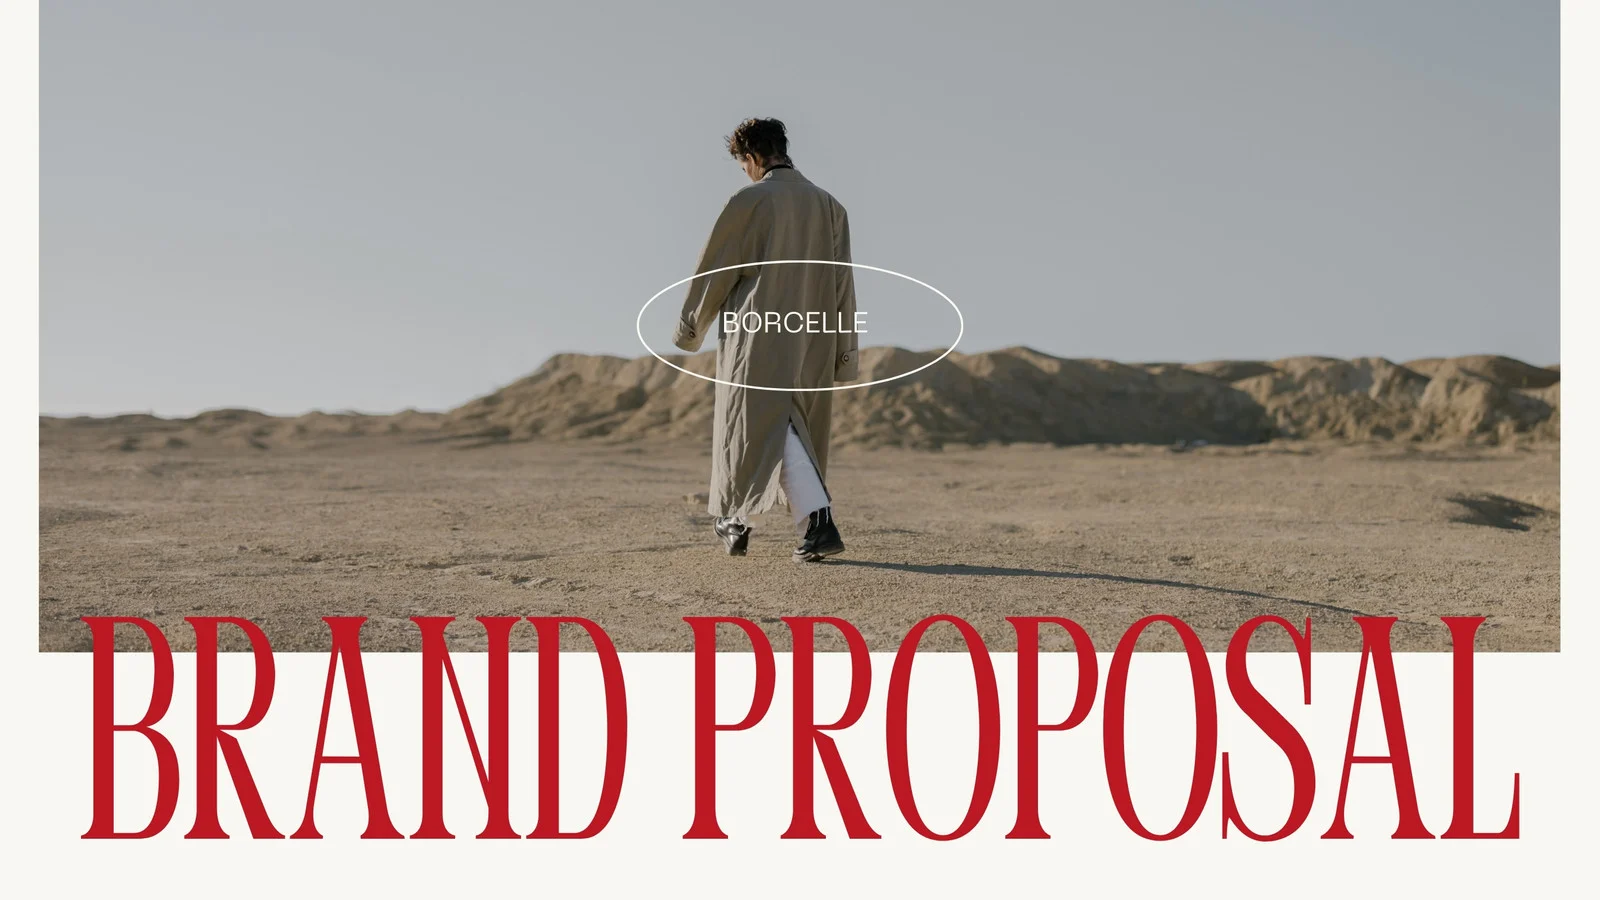

thinking content: Got it, let's rate this graphic design. First, visual balance: the image has a person in the middle with a desert background, and the text elements. The top part is the landscape with the person, and the bottom is bold text. The composition feels balanced with the person centered, the text at the bottom. Color harmony: the desert is earthy tones, the person's coat is beige, the sky is light gray, so muted and cohesive. The "BORCELLE" text in the oval is white, which stands out against the sky and background. The big red text "BRAND PROPOSAL" contrasts well with the white background, which is a bright contrast. Typography: the red text is bold, sans-serif, modern. The "BORCELLE" is a clean, sans-serif oval text. Composition: the layout is clean, with the person as a focal point, the text arranged to guide the eye. Overall design quality: it's professional, minimalist, with a strong visual hierarchy. But let's check each factor:

Visual balance: Yes, the elements are we

In [20]:
import random
from IPython.display import Image as DisplayImage, display
from PIL import Image as PILImage

# pick a random Canva image and show it at 1/4 size
rand_img = random.choice(canva_images)
pil_img = PILImage.open(rand_img).convert("RGB")
rw, rh = pil_img.size
display(DisplayImage(filename=str(rand_img), width=max(1, rw // 4)))

# build multimodal message with PIL image directly
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "role": "system", "text": "Rate the aesthetic quality of this graphic design on a scale from 0 to 100. Consider factors like visual balance, color harmony, typography, composition, and overall design quality. Respond with ONLY a number between 0 and 100, nothing else."},
            {"type": "image", "image": pil_img},
        ],
    }
]

# process inputs (apply_chat_template handles everything)
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

# generate
outputs = model.generate(**inputs, max_new_tokens=8192)
output_ids = outputs[0][inputs["input_ids"].shape[-1]:].tolist()

# parse thinking content (151668 = </think>)
try:
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = processor.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = processor.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

print("thinking content:", thinking_content)
print("content:", content)

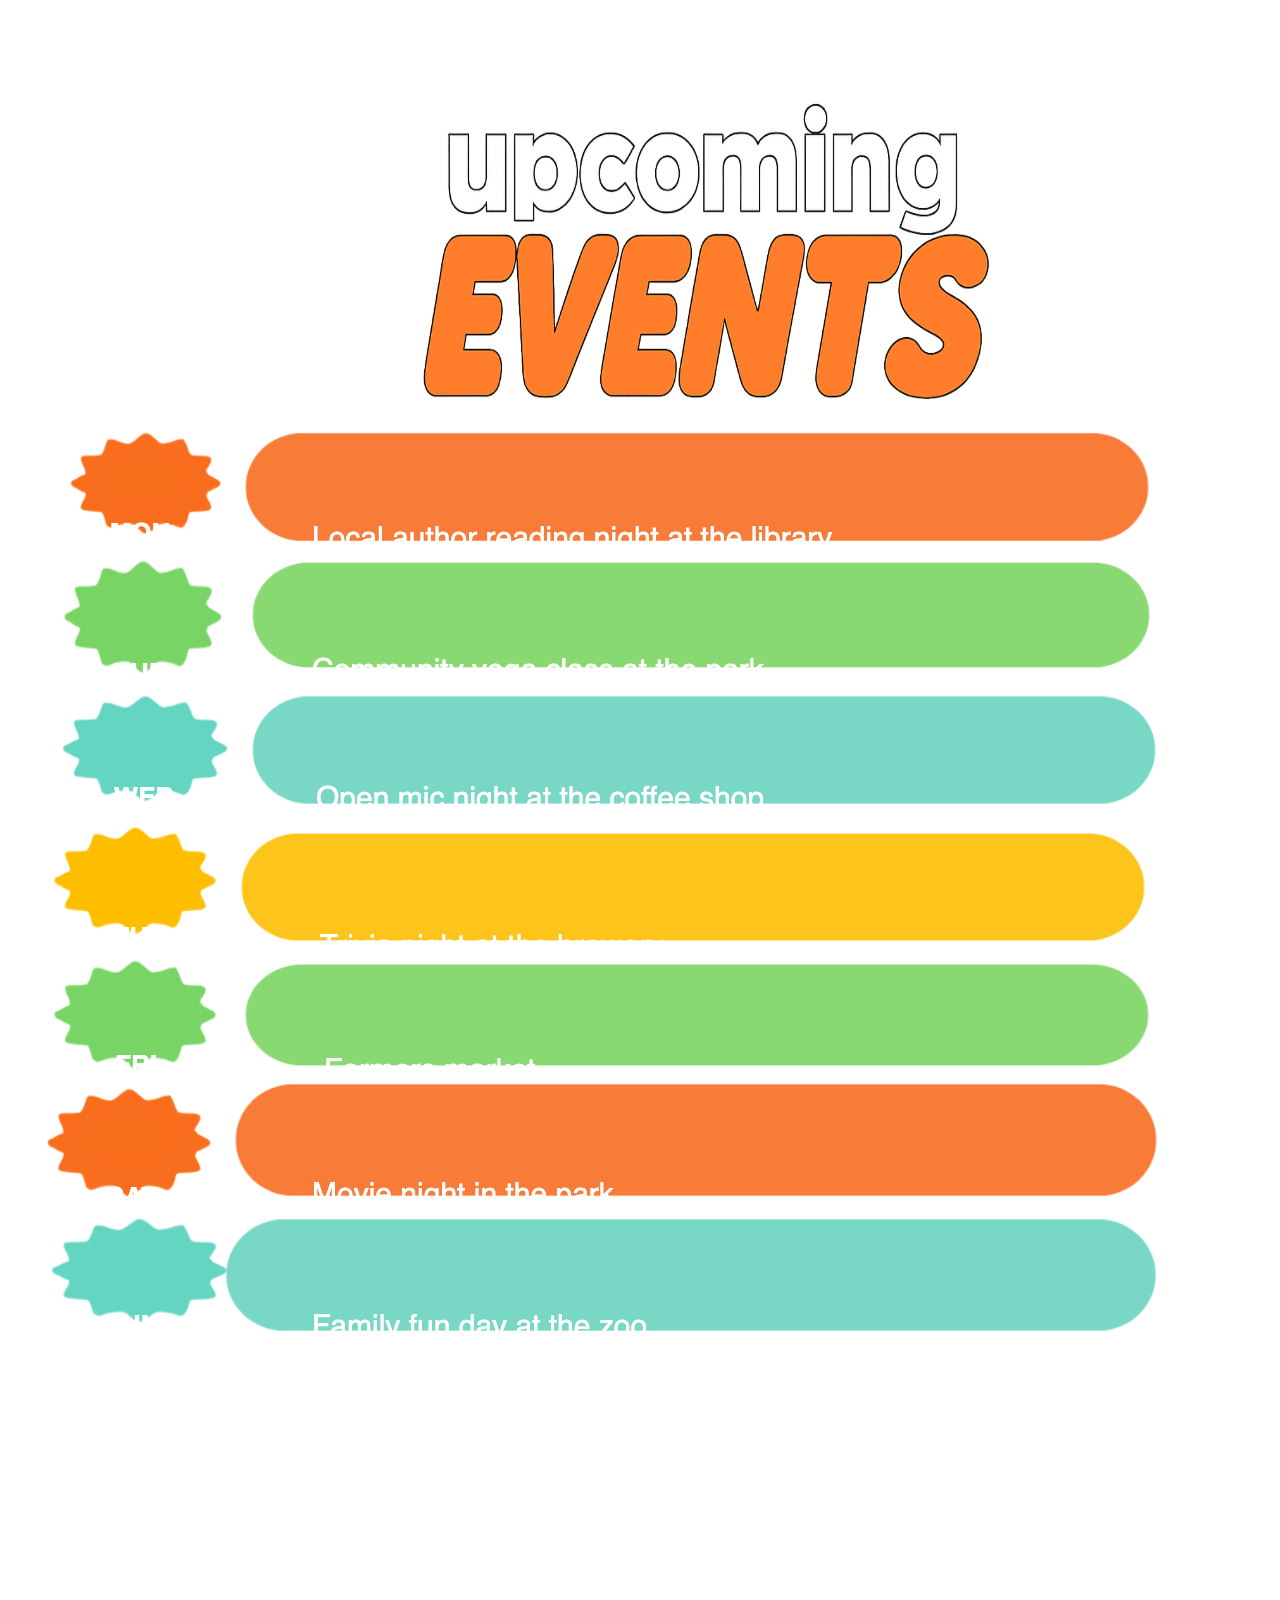

Got it, let's rate this graphic design. First, look at the elements: the title "upcoming EVENTS" with "upcoming" in white and "EVENTS" in orange. Then each event has a colored bar, a day icon (sun, star, etc.), and the event name.

Visual balance: The layout is vertical with events stacked, each with a colored bar and icon. The colors are varied but not too chaotic. The title is centered at the top, which is good.

Color harmony: The colors are bright and vibrant—orange, green, teal, yellow. They form a sort of rainbow, which is nice, but maybe some repetition (like orange and green appearing multiple times). The color scheme is cohesive for a fun, event-oriented design.

Typography: "upcoming" is in a sans-serif, slightly rounded, white. "EVENTS" is bold, orange, also sans-serif. The event names are smaller, probably sans-serif too. Font choice is modern and clear. However, some event names are cut off, like "Local author reading night at the library"—maybe the text is too long, but m

In [53]:
from ollama import chat
from ollama import ChatResponse
from PIL import Image as PILImage
from IPython.display import Image as DisplayImage
import random

# pick a random Canva image and show it at 1/4 size
rand_img = random.choice(edit_images)  # path-like object
pil_img = PILImage.open(rand_img).convert("RGB")
rw, rh = pil_img.size
display(DisplayImage(filename=str(rand_img), width=max(1, rw // 4)))

system_prompt = (
    "Rate the aesthetic quality of this graphic design on a scale from 0 to 100. "
    "Consider factors like visual balance, color harmony, typography, composition, "
    "and overall design quality. Respond with ONLY a number between 0 and 100, "
    "nothing else."
)

messages = [
    {
        "role": "system",
        "content": system_prompt,
    },
    {
        "role": "user",
        "content": "Here is the design to rate.",
        # ✅ Ollama-style multimodal: image paths in `images`, NOT in `content`
        "images": [str(rand_img)],
    },
]

response: ChatResponse = chat(model='qwen3-vl:4b', messages=messages)

# ChatResponse is a pydantic model; safest is to use attributes:
print(response.message.thinking)
print(response.message.content)
